In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site1data.csv')


In [3]:
data

,Date,AVG_NO_USER,DL_TRAFFIC_MB,AVG_USR_THRPUT_DL
0,9/1/2022 0:00,169.37,467047.31,2.626667
1,9/2/2022 0:00,185.25,500334.25,1.733333
2,9/3/2022 0:00,176.34,490534.07,2.343333
3,9/4/2022 0:00,165.04,458040.65,2.800000
4,9/5/2022 0:00,169.75,453424.37,2.530000
...,...,...,...,...
361,8/28/2023 0:00,256.67,885757.79,10.800000
362,8/29/2023 0:00,249.16,882327.23,11.790833
363,8/30/2023 0:00,250.94,916696.52,11.012500
364,8/31/2023 0:00,256.63,905968.97,11.706667


Training with units=50, dropout_rate=0.2, batch_size=32, epochs=50, optimizer=adam
Epoch 1/50
9/9 [==============================] - 7s 183ms/step - loss: 0.0641 - val_loss: 0.0890 - lr: 0.0010
Epoch 2/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0499 - val_loss: 0.0701 - lr: 0.0010
Epoch 3/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0365 - val_loss: 0.0514 - lr: 0.0010
Epoch 4/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0236 - val_loss: 0.0330 - lr: 0.0010
Epoch 5/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0130 - val_loss: 0.0170 - lr: 0.0010
Epoch 6/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0058 - val_loss: 0.0067 - lr: 0.0010
Epoch 7/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0036 - val_loss: 0.0030 - lr: 0.0010
Epoch 8/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0035 - val_loss: 0.0026 - lr: 0.0010
Epoch 9/50
9/9 [=========================

9/9 [==============================] - 0s 6ms/step - loss: 0.0203 - val_loss: 0.0277 - lr: 0.0010
Epoch 5/100
9/9 [==============================] - 0s 7ms/step - loss: 0.0097 - val_loss: 0.0130 - lr: 0.0010
Epoch 6/100
9/9 [==============================] - 0s 7ms/step - loss: 0.0045 - val_loss: 0.0046 - lr: 0.0010
Epoch 7/100
9/9 [==============================] - 0s 6ms/step - loss: 0.0034 - val_loss: 0.0024 - lr: 0.0010
Epoch 8/100
9/9 [==============================] - 0s 7ms/step - loss: 0.0039 - val_loss: 0.0026 - lr: 0.0010
Epoch 9/100
9/9 [==============================] - 0s 6ms/step - loss: 0.0036 - val_loss: 0.0039 - lr: 0.0010
Epoch 10/100
9/9 [==============================] - 0s 6ms/step - loss: 0.0034 - val_loss: 0.0047 - lr: 0.0010
Epoch 11/100
9/9 [==============================] - 0s 7ms/step - loss: 0.0034 - val_loss: 0.0050 - lr: 0.0010
Epoch 12/100
9/9 [==============================] - 0s 6ms/step - loss: 0.0034 - val_loss: 0.0045 - lr: 0.0010
Epoch 13/100
9/9 [=

9/9 [==============================] - 0s 9ms/step - loss: 0.0393 - val_loss: 0.0550 - lr: 0.0010
Epoch 3/150
9/9 [==============================] - 0s 7ms/step - loss: 0.0261 - val_loss: 0.0386 - lr: 0.0010
Epoch 4/150
9/9 [==============================] - 0s 7ms/step - loss: 0.0164 - val_loss: 0.0250 - lr: 0.0010
Epoch 5/150
9/9 [==============================] - 0s 8ms/step - loss: 0.0094 - val_loss: 0.0145 - lr: 0.0010
Epoch 6/150
9/9 [==============================] - 0s 8ms/step - loss: 0.0054 - val_loss: 0.0080 - lr: 0.0010
Epoch 7/150
9/9 [==============================] - 0s 8ms/step - loss: 0.0039 - val_loss: 0.0054 - lr: 0.0010
Epoch 8/150
9/9 [==============================] - 0s 8ms/step - loss: 0.0036 - val_loss: 0.0047 - lr: 0.0010
Epoch 9/150
9/9 [==============================] - 0s 8ms/step - loss: 0.0037 - val_loss: 0.0052 - lr: 0.0010
Epoch 10/150
9/9 [==============================] - 0s 8ms/step - loss: 0.0035 - val_loss: 0.0041 - lr: 0.0010
Epoch 11/150
9/9 [===

5/5 [==============================] - 7s 404ms/step - loss: 0.0626 - val_loss: 0.0848 - lr: 0.0010
Epoch 2/50
5/5 [==============================] - 0s 12ms/step - loss: 0.0491 - val_loss: 0.0713 - lr: 0.0010
Epoch 3/50
5/5 [==============================] - 0s 10ms/step - loss: 0.0398 - val_loss: 0.0600 - lr: 0.0010
Epoch 4/50
5/5 [==============================] - 0s 10ms/step - loss: 0.0321 - val_loss: 0.0492 - lr: 0.0010
Epoch 5/50
5/5 [==============================] - 0s 11ms/step - loss: 0.0249 - val_loss: 0.0395 - lr: 0.0010
Epoch 6/50
5/5 [==============================] - 0s 11ms/step - loss: 0.0188 - val_loss: 0.0308 - lr: 0.0010
Epoch 7/50
5/5 [==============================] - 0s 11ms/step - loss: 0.0137 - val_loss: 0.0226 - lr: 0.0010
Epoch 8/50
5/5 [==============================] - 0s 11ms/step - loss: 0.0096 - val_loss: 0.0163 - lr: 0.0010
Epoch 9/50
5/5 [==============================] - 0s 10ms/step - loss: 0.0067 - val_loss: 0.0124 - lr: 0.0010
Epoch 10/50
5/5 [===

Epoch 5/100
5/5 [==============================] - 0s 11ms/step - loss: 0.0226 - val_loss: 0.0354 - lr: 0.0010
Epoch 6/100
5/5 [==============================] - 0s 10ms/step - loss: 0.0164 - val_loss: 0.0269 - lr: 0.0010
Epoch 7/100
5/5 [==============================] - 0s 10ms/step - loss: 0.0118 - val_loss: 0.0200 - lr: 0.0010
Epoch 8/100
5/5 [==============================] - 0s 11ms/step - loss: 0.0082 - val_loss: 0.0144 - lr: 0.0010
Epoch 9/100
5/5 [==============================] - 0s 11ms/step - loss: 0.0058 - val_loss: 0.0110 - lr: 0.0010
Epoch 10/100
5/5 [==============================] - 0s 10ms/step - loss: 0.0047 - val_loss: 0.0077 - lr: 0.0010
Epoch 11/100
5/5 [==============================] - 0s 11ms/step - loss: 0.0038 - val_loss: 0.0069 - lr: 0.0010
Epoch 12/100
5/5 [==============================] - 0s 11ms/step - loss: 0.0037 - val_loss: 0.0050 - lr: 0.0010
Epoch 13/100
5/5 [==============================] - 0s 11ms/step - loss: 0.0035 - val_loss: 0.0043 - lr: 0.00

...

Epoch 9/150
5/5 [==============================] - 0s 14ms/step - loss: 0.0046 - val_loss: 0.0019 - lr: 0.0010
Epoch 10/150
5/5 [==============================] - 0s 14ms/step - loss: 0.0030 - val_loss: 0.0039 - lr: 0.0010
Epoch 11/150
5/5 [==============================] - 0s 14ms/step - loss: 0.0029 - val_loss: 0.0055 - lr: 0.0010
Epoch 12/150
5/5 [==============================] - 0s 13ms/step - loss: 0.0031 - val_loss: 0.0055 - lr: 0.0010
Epoch 13/150
5/5 [==============================] - 0s 15ms/step - loss: 0.0030 - val_loss: 0.0045 - lr: 0.0010
Epoch 14/150
5/5 [==============================] - 0s 14ms/step - loss: 0.0029 - val_loss: 0.0036 - lr: 0.0010
Epoch 15/150
5/5 [==============================] - 0s 14ms/step - loss: 0.0028 - val_loss: 0.0032 - lr: 0.0010
Epoch 16/150
5/5 [==============================] - 0s 18ms/step - loss: 0.0028 - val_loss: 0.0034 - lr: 0.0010
Epoch 17/150
5/5 [==============================] - 0s 13ms/step - loss: 0.0028 - val_loss: 0.0036 - lr: 

3/3 [==============================] - 2s 3ms/step
MSE (normalized): 0.10521393654056412
Training with units=150, dropout_rate=0.4, batch_size=32, epochs=50, optimizer=rmsprop
Epoch 1/50
9/9 [==============================] - 7s 240ms/step - loss: 0.0534 - val_loss: 0.0647 - lr: 0.0010
Epoch 2/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0297 - val_loss: 0.0375 - lr: 0.0010
Epoch 3/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0142 - val_loss: 0.0185 - lr: 0.0010
Epoch 4/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0062 - val_loss: 0.0081 - lr: 0.0010
Epoch 5/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0039 - val_loss: 0.0054 - lr: 0.0010
Epoch 6/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0038 - val_loss: 0.0055 - lr: 0.0010
Epoch 7/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0038 - val_loss: 0.0045 - lr: 0.0010
Epoch 8/50
9/9 [==============================] - 0s 1

9/9 [==============================] - 0s 10ms/step - loss: 0.0035 - val_loss: 0.0054 - lr: 0.0010
Epoch 17/100
9/9 [==============================] - 0s 10ms/step - loss: 0.0035 - val_loss: 0.0039 - lr: 0.0010
Epoch 18/100
9/9 [==============================] - 0s 10ms/step - loss: 0.0034 - val_loss: 0.0074 - lr: 0.0010
Epoch 19/100
9/9 [==============================] - 0s 9ms/step - loss: 0.0036 - val_loss: 0.0033 - lr: 0.0010
Epoch 20/100
9/9 [==============================] - 0s 9ms/step - loss: 0.0033 - val_loss: 0.0036 - lr: 0.0010
Epoch 21/100
3/3 [==============================] - 1s 3ms/step
MSE (normalized): 0.15323689374734473
Training with units=150, dropout_rate=0.4, batch_size=32, epochs=150, optimizer=adam
Epoch 1/150
9/9 [==============================] - 9s 217ms/step - loss: 0.0576 - val_loss: 0.0679 - lr: 0.0010
Epoch 2/150
9/9 [==============================] - 0s 12ms/step - loss: 0.0303 - val_loss: 0.0294 - lr: 0.0010
Epoch 3/150
9/9 [============================

5/5 [==============================] - 0s 14ms/step - loss: 0.0039 - val_loss: 0.0052 - lr: 0.0010
Epoch 14/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0038 - val_loss: 0.0054 - lr: 0.0010
Epoch 15/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0036 - val_loss: 0.0054 - lr: 0.0010
Epoch 16/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0037 - val_loss: 0.0063 - lr: 0.0010
Epoch 17/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0037 - val_loss: 0.0063 - lr: 0.0010
Epoch 18/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0036 - val_loss: 0.0055 - lr: 0.0010
Epoch 19/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0037 - val_loss: 0.0051 - lr: 0.0010
Epoch 20/50
5/5 [==============================] - 0s 16ms/step - loss: 0.0036 - val_loss: 0.0070 - lr: 0.0010
Epoch 21/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0036 - val_loss: 0.0055 - lr: 0.0010
Epoch 22/50
3

5/5 [==============================] - 0s 18ms/step - loss: 0.0030 - val_loss: 0.0035 - lr: 0.0010
Epoch 44/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0030 - val_loss: 0.0027 - lr: 0.0010
Epoch 45/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0031 - val_loss: 0.0038 - lr: 0.0010
Epoch 46/100
5/5 [==============================] - 0s 15ms/step - loss: 0.0030 - val_loss: 0.0058 - lr: 0.0010
Epoch 47/100
5/5 [==============================] - 0s 18ms/step - loss: 0.0031 - val_loss: 0.0048 - lr: 0.0010
Epoch 48/100
5/5 [==============================] - 0s 16ms/step - loss: 0.0029 - val_loss: 0.0023 - lr: 0.0010
Epoch 49/100
5/5 [==============================] - 0s 16ms/step - loss: 0.0031 - val_loss: 0.0038 - lr: 0.0010
Epoch 50/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0029 - val_loss: 0.0031 - lr: 0.0010
Epoch 51/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0029 - val_loss: 0.0034 - lr: 0.0010
Epoch

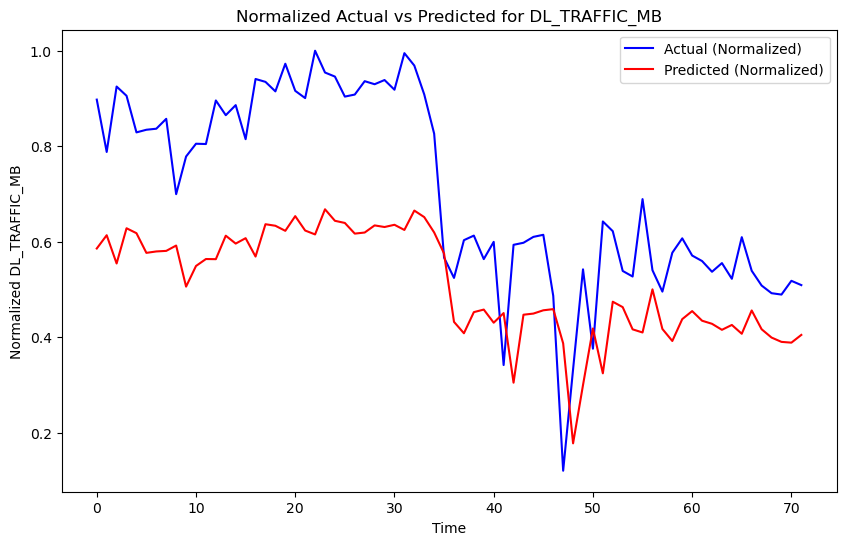

In [4]:

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, :])
    return np.array(X), np.array(Y)

# Function to build and train LSTM model with given hyperparameters
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'AVG_NO_USER' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=1)
X_train, y_train = create_dataset(train, look_back=1)
X_test, y_test = create_dataset(test, look_back=1)

# Reshape input data to 3D (samples, timesteps, features) for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Manual hyperparameter tuning loop
best_mse = float('inf')
best_params = {}
best_model = None
best_history = None

# Loop through different hyperparameter configurations
for units in [50, 100, 150]:
    for dropout_rate in [0.2, 0.3, 0.4]:
        for batch_size in [32, 64]:
            for epochs in [50, 100, 150]:
                for optimizer in ['adam', 'rmsprop']:
                    print(f'Training with units={units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}, optimizer={optimizer}')
                    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
                    
                    # Calculate MSE with normalized data
                    mse = mean_squared_error(y_test, test_predict)
                    print(f'MSE (normalized): {mse}')
                    
                    # Track the best model
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'units': units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs, 'optimizer': optimizer}
                        best_model = model
                        best_history = history

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Plot the best model's predictions with normalized values
best_test_predict = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature}')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()